# Langevin Polynomial Chaos

This notebook uses the `LangevinGroup` for stochastic coefficient sampling.

In [1]:
import corner
import matplotlib.pyplot as plt
import torch

from pypolymix import StochasticModel
from pypolymix.parameter_groups import LangevinGroup
from pypolymix.surrogate_models import NeuralNetwork, PolynomialChaosExpansion

In [2]:
_ = torch.manual_seed(1234)

n_train = 25
X = 2 * torch.rand(n_train, 1) - 1
Y = torch.sin(torch.pi * X) + 0.1 * torch.randn_like(X)

In [3]:
# Base surrogate whose parameters we want to sample
surrogate_model = PolynomialChaosExpansion(num_inputs=1, num_outputs=1, degree=5)
num_params = surrogate_model.num_params()

# Score surrogate reused from pypolymix.surrogate_models
score_model = NeuralNetwork(
    num_inputs=num_params,
    num_outputs=num_params,
    width=32,
    depth=2,
    activation=torch.nn.functional.tanh,
)

group = LangevinGroup(
    name="langevin_coeffs",
    num_params=num_params,
    score_model=score_model,
    num_particles=64,
    num_diffusion_steps=128,
    step_size=1e-2, # Between 1 and 10 total psdeudo-time units is recommended, so step_size * num_diffusion_steps should be in that range
)

model = StochasticModel(surrogate_model=surrogate_model, parameter_groups=[group])

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
loss_fn = torch.nn.MSELoss(reduction="mean")
weight_factor = 1e-6
num_epochs = 1000
num_samples = 100

for epoch in range(num_epochs):
    optimizer.zero_grad()
    preds = model(X, num_samples=num_samples)
    data_loss = loss_fn(preds, Y.unsqueeze(0).expand_as(preds)) / num_samples
    loss = data_loss + weight_factor * model.distribution_loss()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 100/1000, Loss: 0.0091
Epoch 200/1000, Loss: 0.0033
Epoch 300/1000, Loss: 0.0019
Epoch 400/1000, Loss: 0.0014
Epoch 500/1000, Loss: 0.0011
Epoch 600/1000, Loss: 0.0009
Epoch 700/1000, Loss: 0.0009
Epoch 800/1000, Loss: 0.0009
Epoch 900/1000, Loss: 0.0008
Epoch 1000/1000, Loss: 0.0006


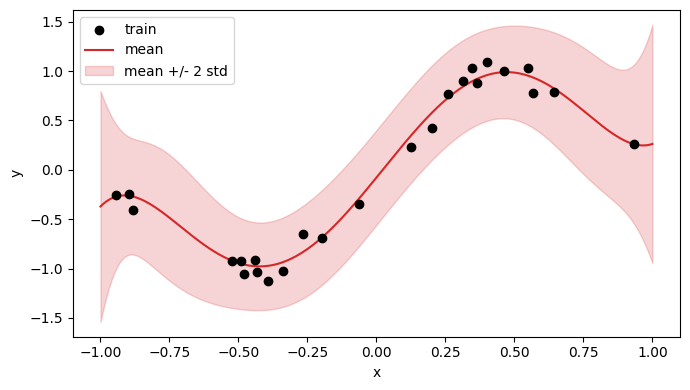

In [5]:
with torch.no_grad():
    X_test = torch.linspace(-1, 1, 201).unsqueeze(-1)
    samples = model(X_test, num_samples=512).squeeze(-1)
    mean = samples.mean(dim=0)
    std = samples.std(dim=0)

_, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X.squeeze(-1), Y.squeeze(-1), color="black", label="train", zorder=3)
ax.plot(X_test.squeeze(-1), mean, color="tab:red", label="mean")
ax.fill_between(
    X_test.squeeze(-1),
    mean - 2.0 * std,
    mean + 2.0 * std,
    color="tab:red",
    alpha=0.2,
    label="mean +/- 2 std",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()

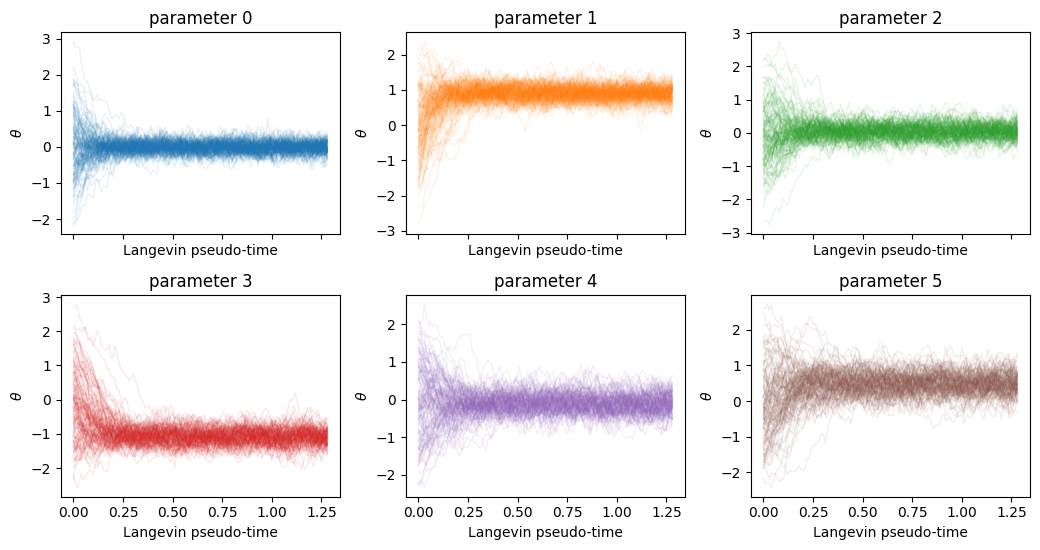

In [6]:
# Plot Langevin particle trajectories for each surrogate parameter
group = model.parameter_groups[0]
num_particles = 128

with torch.no_grad():
    theta = torch.randn(
        num_particles,
        group.num_params,
        device=group.score_params.device,
        dtype=group.score_params.dtype,
    ) * group.init_std
    traj = [theta.detach().cpu()]
    noise_scale = torch.sqrt(
        torch.tensor(2.0 * group.step_size, device=group.score_params.device, dtype=group.score_params.dtype)
    )

    for _ in range(group.num_diffusion_steps):
        drift = group.step_size * group._score(theta)
        diffusion = noise_scale * torch.randn_like(theta)
        theta = theta + drift + diffusion
        traj.append(theta.detach().cpu())

traj = torch.stack(traj, dim=0)  # (steps + 1, particles, num_params)
steps = torch.arange(traj.shape[0])
num_params = traj.shape[-1]

ncols = min(3, num_params)
nrows = (num_params + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 2.8 * nrows), sharex=True)
if hasattr(axes, "flatten"):
    axes = axes.flatten().tolist()
else:
    axes = [axes]

for j in range(num_params):
    ax = axes[j]
    for p in range(num_particles):
        ax.plot(steps * group.step_size, traj[:, p, j], color=f"C{j}", alpha=0.1, linewidth=1.0)
    ax.set_title(f"parameter {j}")
    ax.set_ylabel(r"$\theta$")

for ax in axes[num_params:]:
    ax.axis("off")

for ax in axes[:num_params]:
    ax.set_xlabel("Langevin pseudo-time")

plt.tight_layout()

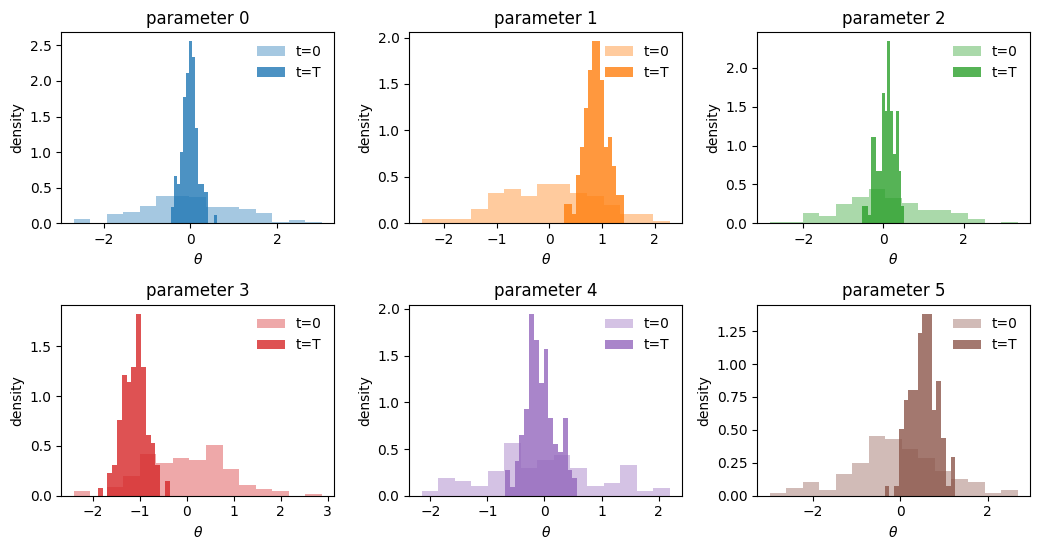

In [7]:
# Plot particle distributions at initial and final Langevin pseudo-times
with torch.no_grad():
      # "First time" distribution (same initialization used by LangevinGroup)
      theta0 = torch.randn(
          num_particles,
          group.num_params,
          device=group.score_params.device,
          dtype=group.score_params.dtype,
      ) * group.init_std

      # "Last time" distribution from Langevin dynamics
      thetaT = group.sample_parameters(num_samples=num_particles)

theta0 = theta0.cpu()
thetaT = thetaT.cpu()

n_params = theta0.shape[1]
ncols = min(3, n_params)
nrows = (n_params + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 2.8 * nrows))
if hasattr(axes, "flatten"):
    axes = axes.flatten()
else:
    axes = [axes]

for j in range(n_params):
    ax = axes[j]
    ax.hist(theta0[:, j], bins=15, density=True, alpha=0.4, color=f"C{j}", label="t=0")
    ax.hist(thetaT[:, j], bins=15, density=True, alpha=0.8, color=f"C{j}", label="t=T")
    ax.set_title(f"parameter {j}")
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel("density")
    ax.legend(frameon=False, loc="upper right")

for ax in axes[n_params:]:
    ax.axis("off")

plt.tight_layout()

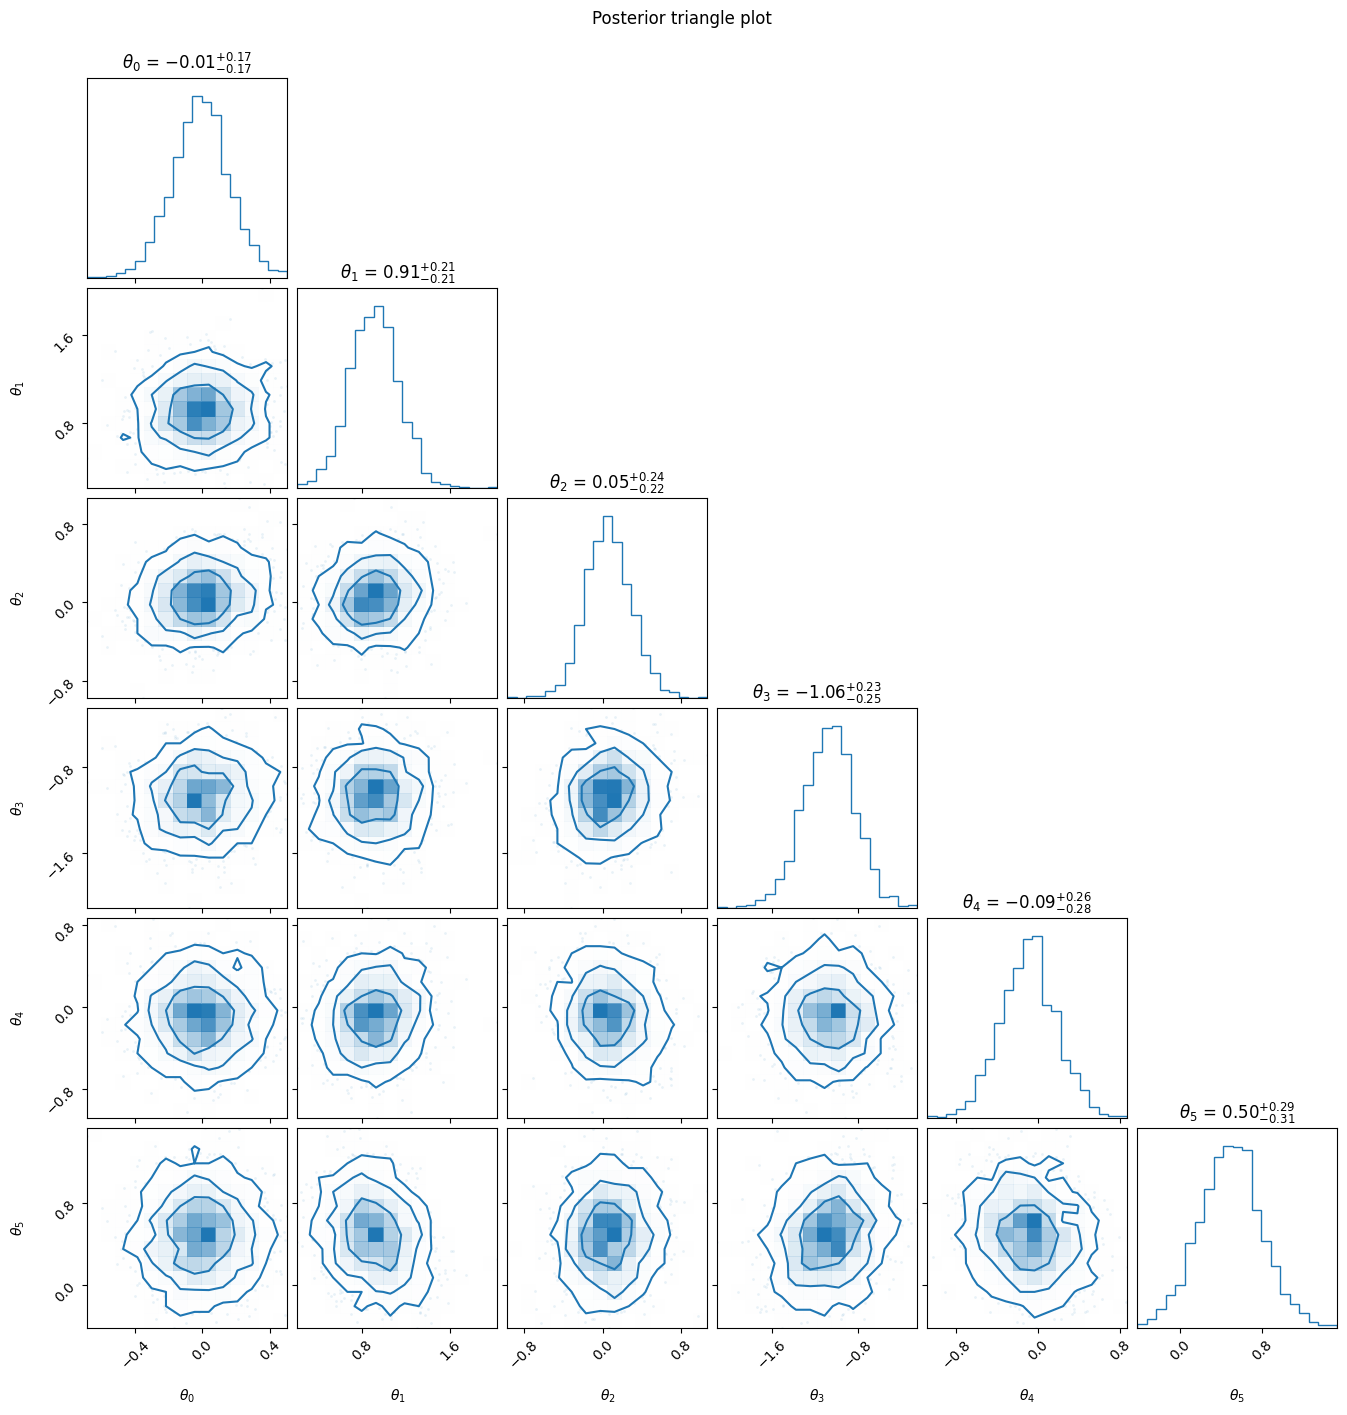

In [8]:
# Plot a corner-style view of the final parameter samples
with torch.no_grad():
    posterior_samples = group.sample_parameters(num_samples=2048).cpu().numpy()

labels = [fr"$\theta_{j}$" for j in range(posterior_samples.shape[1])]
corner.corner(
    posterior_samples,
    labels=labels,
    bins=14,
    show_titles=True,
    title_fmt=".2f",
    plot_datapoints=True,
    plot_density=True,
    plot_contours=True,
    fill_contours=False,
    levels=(0.5, 0.8, 0.95),
    hist_bin_factor=1.5,
    max_n_ticks=3,
    color="C0"
)
plt.suptitle("Posterior triangle plot", y=1.02)
plt.show()